# Neural Network

In this lab you will repeat the k-Nearest Neighbors tuning experiment with a neural network.

As before, you will use the [Fashion MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) provided by the [Keras library](https://keras.io/api/datasets/fashion_mnist/).  You will need to install Keras and PyTorch to access the dataset.

In [1]:
%pip install keras torch

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 73.6 MB 7.9 MB/s eta 0:00:01
     |████████████████████████████████| 200 kB 21.2 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 30.3 MB/s eta 0:00:01
     |████████████████████████████████| 134 kB 12.6 MB/s eta 0:00:01
     |████████████████████████████████| 6.3 MB 20.5 MB/s eta 0:00:01
     |████████████████████████████████| 536 kB 10.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import glob
import imageio
import skimage
from matplotlib import pyplot as plt
import numpy as np

from sklearn.neural_network import MLPClassifier

import os
os.environ['KERAS_BACKEND'] = 'torch'

from keras.datasets import fashion_mnist

import tqdm

Matplotlib is building the font cache; this may take a moment.
/Users/jhuynh/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Here we load the dataset and show some example images.  Each class is a different category of clothing like shoe, t-shirt, or dress.  The classes are mostly distinguishable by shape, and so they are a good candidate for classification using the [HOG (Histogram of Gradients)](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_hog.html) descriptor which captures shape well.

In [2]:
(train_images,train_labels),(val_images,val_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


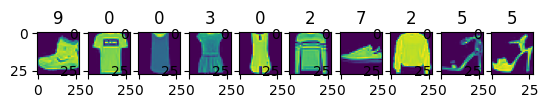

In [3]:
fig,axes = plt.subplots(1,10)
for i,ax in enumerate(axes):
    axes[i].imshow(train_images[i])
    axes[i].set_title(train_labels[i])

Now what we have are lists `train_images` and `train_labels` containing the images and labels for the training set, and the same for the validation set.

Here we will compute the HOG descriptor for each image to make two lists, `train_descriptors` and `val_descriptors` (```skimage.feature.hog```).

In [4]:
train_descriptors = list(map(skimage.feature.hog,train_images))
val_descriptors = list(map(skimage.feature.hog,val_images))

In [5]:
train_descriptors = np.vstack(train_descriptors)
val_descriptors = np.vstack(val_descriptors)

In [6]:
train_descriptors.shape

(60000, 81)

1. Build a neural network (MLP) classifier on the training set (```sklearn.neural_network.MLPClassifier```).

Use the default configuration, except set `max_iter=1000`.

Run the model on the test set and print out the accuracy (```sklearn.metrics.accuracy_score``` or simply use ```model.score```).

In [7]:
nn = MLPClassifier(max_iter=1000).fit(train_descriptors, train_labels)
nn.score(val_descriptors, val_labels)

0.8368

2. Test different settings of the `alpha` parameter to `MLPClassifier`, which controls the strength of regularization (smoothness).  Test on a logarithmic scale $10^-k$ where $k=0,\ldots,5$.  Analyze the trade-off between over- and underfitting changes as $k$ increases.  Which is the best setting of `alpha`?

In [ ]:
accuracies = []
for k in range(6):
  nn = MLPClassifier(max_iter=1000, alpha=(10 ** (-k))).fit(train_descriptors, train_labels)
  accuracies.append(nn.score(val_descriptors, val_labels))


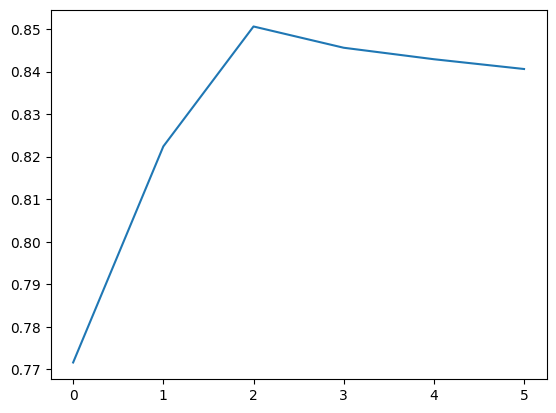

In [9]:
plt.plot([k for k in range(6)], accuracies)
plt.show()

The tradeoff of overfitting is that accuracy decreases the more you increase the value of k. The best value of k is 2.